<a href="https://colab.research.google.com/github/adanisalsabila/Algoritma_dan_Struktur_Data_1G_01/blob/main/Week7_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [31]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

Gambar berhasil dimuat dan dikonversi ke Grayscale.


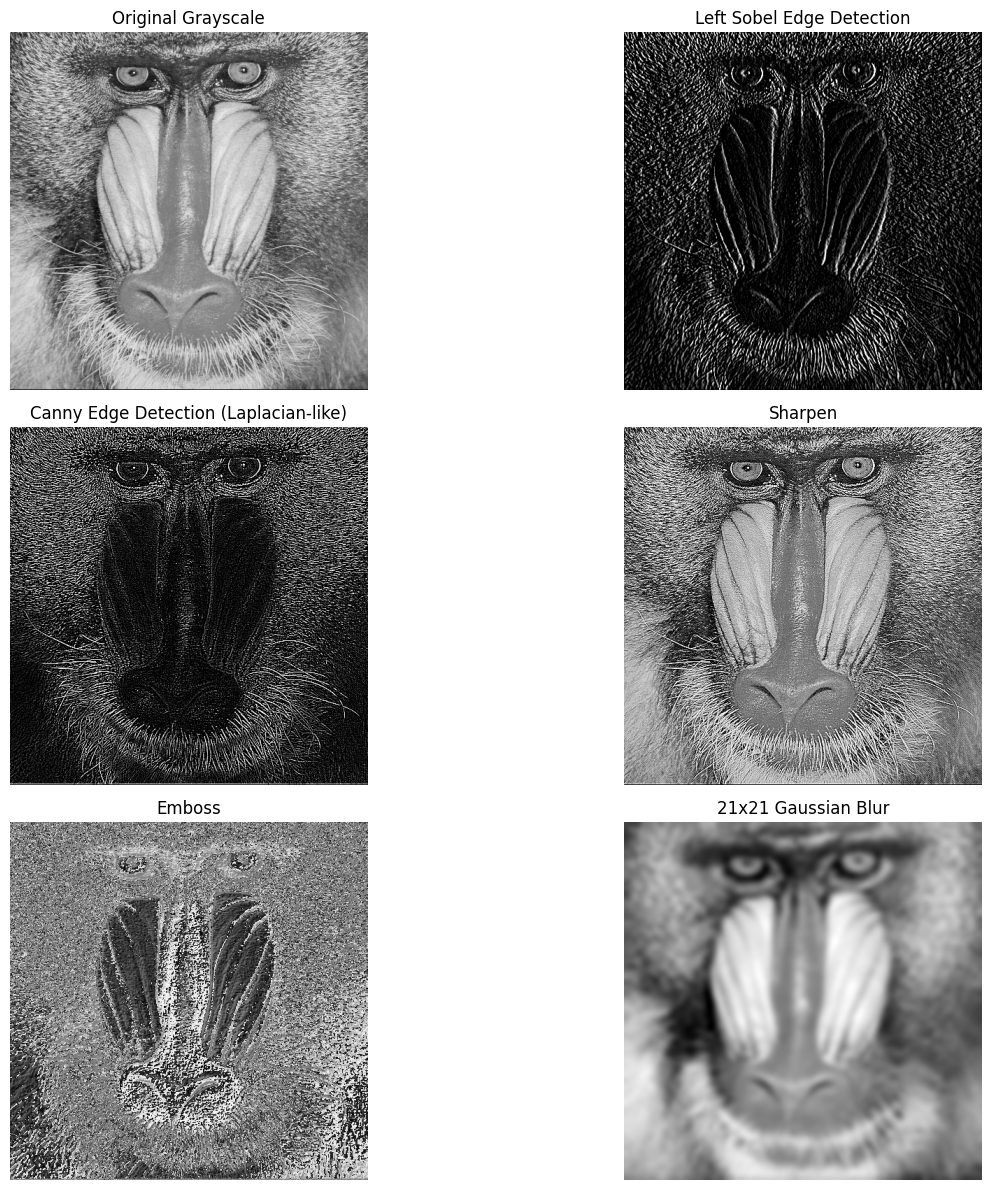

In [32]:
try:
    img = cv.imread('/content/drive/MyDrive/PCVK25_3F_01/mandrill.tiff')
    if img is None:
        raise FileNotFoundError("Gagal memuat gambar. Pastikan jalur file sudah benar.")
    img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    print("Gambar berhasil dimuat dan dikonversi ke Grayscale.")
except FileNotFoundError as e:
    print(e)
    img_gray = np.zeros((512, 512), dtype=np.uint8)
    print("Menggunakan array dummy 512x512. Operasi filter akan berjalan, tetapi hasilnya kosong.")

# a. Left Sobel Edge Detection Kernel (Hx)
kernel_sobel_left = np.array([[1, 0, -1],
                              [2, 0, -2],
                              [1, 0, -1]])

# b. "Canny Edge Detection" Kernel (Ini adalah kernel Laplacian-like)
kernel_laplacian = np.array([[-1, -1, -1],
                             [-1, 8, -1],
                             [-1, -1, -1]])

# c. Sharpen Kernel
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])

# d. Emboss Kernel
kernel_emboss = np.array([[-2, -1, 0],
                          [-1, 1, 1],
                          [0, 1, 2]])

kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel_1d = cv.getGaussianKernel(kernel_size, sigma)
kernel_gaussian_21x21 = gaussian_kernel_1d @ gaussian_kernel_1d.transpose()

result_sobel_left = cv.filter2D(img_gray, -1, kernel_sobel_left)
result_laplacian = cv.filter2D(img_gray, -1, kernel_laplacian)
result_gaussian_blur = cv.filter2D(img_gray, -1, kernel_gaussian_21x21)
result_sharpen = cv.filter2D(img_gray, -1, kernel_sharpen)

result_emboss = cv.filter2D(img_gray, -1, kernel_emboss)
result_emboss_viz = np.clip(result_emboss + 128, 0, 255).astype(np.uint8)

operations = {
    "Original Grayscale": img_gray,
    "Left Sobel Edge Detection": result_sobel_left,
    "Canny Edge Detection (Laplacian-like)": result_laplacian,
    "Sharpen": result_sharpen,
    "Emboss": result_emboss_viz,
    "21x21 Gaussian Blur": result_gaussian_blur,
}

plt.figure(figsize=(15, 12))
for i, (title, image) in enumerate(operations.items()):
    plt.subplot(3, 2, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()


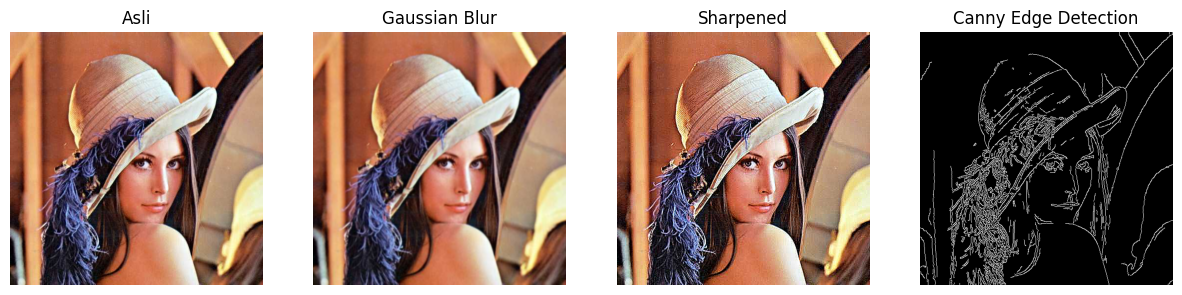

In [35]:
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    num_images = len(images)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:
            plt.subplot(1, num_images, i+1)
            plt.imshow(img, cmap="gray")
        else:
            plt.subplot(1, num_images, i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))

        plt.title(title)
        plt.axis("off")

    plt.show()

img = cv.imread("/content/drive/MyDrive/PCVK25_3F_01/P5/lena.jpg")

if img is None:
    print("Gagal memuat gambar. Harap periksa path file Anda.")
else:
    img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # 1. Gaussian Blur (pada gambar berwarna)
    blur = cv.GaussianBlur(img, (7, 7), 1)

    # 2. Canny Edge Detection (perlu grayscale)
    edges = cv.Canny(img_gray, 100, 200)

    # 3. Sharpen (pada gambar berwarna)
    sharpen_kernel = np.array([[0, -1, 0],
                               [-1, 5, -1],
                               [0, -1, 0]])
    sharpened = cv.filter2D(img, -1, sharpen_kernel)

    show_side_by_side([img, blur, sharpened, edges],
                      ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

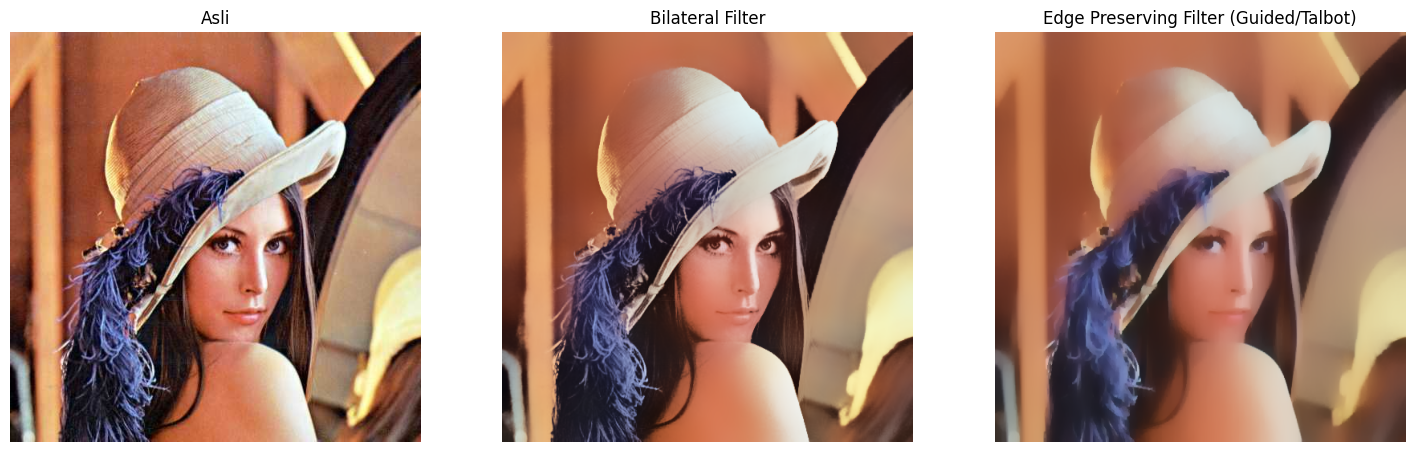

In [39]:
def show_side_by_side(images, titles, figsize=(15,5)):
    """Menampilkan gambar secara berdampingan."""
    plt.figure(figsize=figsize)
    num_images = len(images)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, num_images, i+1)

        if len(img.shape) == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))

        plt.title(title)
        plt.axis("off")

    plt.show()

try:
    img = cv.imread("/content/drive/MyDrive/PCVK25_3F_01/P5/lena.jpg")
    if img is None:
        raise FileNotFoundError("Gagal memuat gambar. Harap periksa path file Anda.")
except FileNotFoundError as e:
    print(e)
    img = np.zeros((256, 256, 3), dtype=np.uint8)
    print("Menggunakan gambar dummy.")

if len(img.shape) == 2:
    img = cv.cvtColor(img, cv.COLOR_GRAY2BGR)

bilateral = cv.bilateralFilter(img, 50, 100, 100)

try:
    edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

except AttributeError:
    print("\n[PERINGATAN]: cv.edgePreservingFilter atau cv.ximgproc mungkin tidak tersedia.")
    print("Pastikan Anda menggunakan 'opencv-contrib-python'. Menggunakan Bilateral Filter untuk perbandingan.")
    edge_preserve = bilateral

show_side_by_side([img, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter (Guided/Talbot)"],
                  figsize=(18, 6))